In [1]:
import os
import sys
repo_path = os.path.abspath(os.path.join(os.getcwd(), "../../"))
sys.path.append(repo_path)

import numpy as np
import matplotlib.pyplot as plt
from utils import load_yaml
from tqdm import tqdm

import dolfinx
import dolfinx.fem.petsc
import ufl
from mpi4py import MPI
import basix.ufl

from data_generation.differential_equations import ElasticityLeastSquares


----------------------------------------
2025-12-11 18:12:50 - Start Program
----------------------------------------


In [2]:
mesh_config_path= repo_path + "/configs/elasticity/config_data/config_mesh.yaml"
function_space_config_path= repo_path + "/configs/elasticity/config_data/config_function_space.yaml"
output_reduced_basis_config_path= repo_path + "/configs/elasticity/config_data/config_output_reduced_basis.yaml"
train_dataset_path = repo_path + "/results/elasticity/train_dataset"
test_dataset_path = repo_path + "/results/elasticity/test_dataset"

mesh_args = load_yaml(mesh_config_path)
function_space_args = load_yaml(function_space_config_path)
output_reduced_basis_args = load_yaml(output_reduced_basis_config_path)
elasticity_least_squares = ElasticityLeastSquares(mesh_args, function_space_args)

In [3]:
num_basis_list = [2**i for i in range(10)]
print(f'num basis list: {num_basis_list}')

num basis list: [1, 2, 4, 8, 16, 32, 64, 128, 256, 512]


In [4]:
num_samples = 500
compute_squared_hdiv_h1_norm = elasticity_least_squares.compute_squared_hdiv_h1_norm
mesh = elasticity_least_squares.mesh
Vh = elasticity_least_squares.Vh

reduced basis MSE Error compared to original high fidelity solution

In [5]:
reduced_basis_mse_error_record = np.zeros((len(num_basis_list), num_samples))

In [6]:
sigma_u_dof = np.load(test_dataset_path+'/sigma_u_dof.npy')[:num_samples]
pod_basis_dof = np.load(test_dataset_path+'/hdiv_h1_pod_basis_dof.npy')[:,:output_reduced_basis_args['num_basis']] 
reference_reduced_minimizers = np.load(test_dataset_path+'/reference_reduced_minimizers.npy')[:num_samples]

In [7]:
mean_p_dof = np.load(test_dataset_path+'/mean_p_dof.npy')
mean_p_fc = dolfinx.fem.Function(Vh['p'])
mean_p_fc.x.array[:] = mean_p_dof

In [8]:
for i, num_basis in enumerate(tqdm(num_basis_list)):
    reduced_basis_sigma_u_dof = reference_reduced_minimizers[:, :num_basis] @ pod_basis_dof[:, :num_basis].T
    for j, sample_index in enumerate(tqdm(range(num_samples))):
        sigma_u_low_rank_fc = dolfinx.fem.Function(Vh['sigma_u'])
        sigma_u_low_rank_fc.x.array[:] = reduced_basis_sigma_u_dof[j]
        sigma_low_rank_fc = sigma_u_low_rank_fc.sub(0).collapse()
        u_low_rank_fc = sigma_u_low_rank_fc.sub(1).collapse()
        sigma1_low_rank_fc, sigma2_low_rank_fc = ufl.split(sigma_low_rank_fc)
        sigma_low_rank_fc_ = ufl.as_vector((sigma1_low_rank_fc, sigma2_low_rank_fc))


        sigma_u_label_fc = dolfinx.fem.Function(Vh['sigma_u'])
        sigma_u_label_fc.x.array[:] = sigma_u_dof[sample_index]
        sigma_label_fc = sigma_u_label_fc.sub(0).collapse()
        u_label_fc = sigma_u_label_fc.sub(1).collapse()
        sigma1_label_fc, sigma2_label_fc = ufl.split(sigma_label_fc)
        sigma_label_fc_ = ufl.as_vector((sigma1_label_fc, sigma2_label_fc))

        difference_sigma_fc = ufl.as_vector((sigma1_low_rank_fc - sigma1_label_fc, sigma2_low_rank_fc - sigma2_label_fc))
        difference_u_fc = u_low_rank_fc - u_label_fc

        reduced_basis_mse_error_record[i, j] = compute_squared_hdiv_h1_norm(difference_sigma_fc, difference_u_fc, mean_p_fc)

100%|██████████| 10/10 [06:10<00:00, 37.02s/it]


In [9]:
mean_reduced_basis_mse_error_record = np.mean(reduced_basis_mse_error_record, axis=1)

In [10]:
mean_reduced_basis_mse_error_record

array([0.25128842, 0.19126879, 0.12239417, 0.0717273 , 0.03850459,
       0.0213571 , 0.0123788 , 0.00747089, 0.00485341, 0.00354121])

Xh Projection error

In [11]:
Xh_projection_error_record = np.zeros((len(num_basis_list), num_samples))

In [12]:
sigma_u_dof = np.load(test_dataset_path+'/sigma_u_dof.npy')[:num_samples]
pod_basis_dof = np.load(test_dataset_path+'/hdiv_h1_pod_basis_dof.npy')[:,:output_reduced_basis_args['num_basis']]
pod_coeff_labels = np.load(test_dataset_path+'/hdiv_h1_pod_coeff_labels.npy')[:num_samples,:output_reduced_basis_args['num_basis']]

In [13]:
mean_p_dof = np.load(test_dataset_path+'/mean_p_dof.npy')
mean_p_fc = dolfinx.fem.Function(Vh['p'])
mean_p_fc.x.array[:] = mean_p_dof

In [14]:
for i, num_basis in enumerate(tqdm(num_basis_list)):
    low_rank_sigma_u_dof = pod_coeff_labels[:, :num_basis] @ pod_basis_dof[:, :num_basis].T
    for j, sample_index in enumerate(tqdm(range(num_samples))):
        sigma_u_low_rank_fc = dolfinx.fem.Function(Vh['sigma_u'])
        sigma_u_low_rank_fc.x.array[:] = low_rank_sigma_u_dof[j]
        sigma_low_rank_fc = sigma_u_low_rank_fc.sub(0).collapse()
        u_low_rank_fc = sigma_u_low_rank_fc.sub(1).collapse()
        sigma1_low_rank_fc, sigma2_low_rank_fc = ufl.split(sigma_low_rank_fc)
        sigma_low_rank_fc_ = ufl.as_vector((sigma1_low_rank_fc, sigma2_low_rank_fc))

        sigma_u_label_fc = dolfinx.fem.Function(Vh['sigma_u'])
        sigma_u_label_fc.x.array[:] = sigma_u_dof[sample_index]
        sigma_label_fc = sigma_u_label_fc.sub(0).collapse()
        u_label_fc = sigma_u_label_fc.sub(1).collapse()
        sigma1_label_fc, sigma2_label_fc = ufl.split(sigma_label_fc)
        sigma_label_fc_ = ufl.as_vector((sigma1_label_fc, sigma2_label_fc))

        difference_sigma_fc = ufl.as_vector((sigma1_low_rank_fc - sigma1_label_fc, sigma2_low_rank_fc - sigma2_label_fc))
        difference_u_fc = u_low_rank_fc - u_label_fc

        Xh_projection_error_record[i, j] = compute_squared_hdiv_h1_norm(difference_sigma_fc, difference_u_fc, mean_p_fc)

100%|██████████| 10/10 [06:08<00:00, 36.82s/it]


In [15]:
mean_Xh_projection_error_record = np.mean(Xh_projection_error_record, axis=1)

In [16]:
mean_Xh_projection_error_record

array([0.25008124, 0.19003709, 0.12108149, 0.0703745 , 0.03711611,
       0.01993818, 0.01092713, 0.00597156, 0.00329162, 0.00190329])

Error estimated by trailing eigenvalues

In [17]:
## Need more eigenvalues

In [18]:
eigenvalues = np.load(os.path.join(train_dataset_path, "hdiv_h1_pod_eigvals_for_analysis.npy"))
num_evals = 1600

In [19]:
error_estimate_by_trailing_eigenvalues_list = []
for i, rank in enumerate(num_basis_list):
    print(f'i {i} | rank {rank}')
    trailing_eigenvalues = eigenvalues[rank+1-1:] 
    sum_squared_trailing_eigenvalues = np.sum(trailing_eigenvalues**2).item() / num_evals
    error_estimate_by_trailing_eigenvalues_list.append(sum_squared_trailing_eigenvalues)

i 0 | rank 1
i 1 | rank 2
i 2 | rank 4
i 3 | rank 8
i 4 | rank 16
i 5 | rank 32
i 6 | rank 64
i 7 | rank 128
i 8 | rank 256
i 9 | rank 512


In [20]:
error_estimate_by_trailing_eigenvalues_list

[0.2523930428134092,
 0.18814346666532752,
 0.11776948104036895,
 0.06565490024774676,
 0.03462520732180707,
 0.01825588494422223,
 0.009199858064434295,
 0.00432809320422692,
 0.0018138055735598352,
 0.0005984822164754634]

In [21]:
markers = ['o', 's', '^', 'D', 'v', '>', '<', 'p', '*', 'h']  # add more if needed

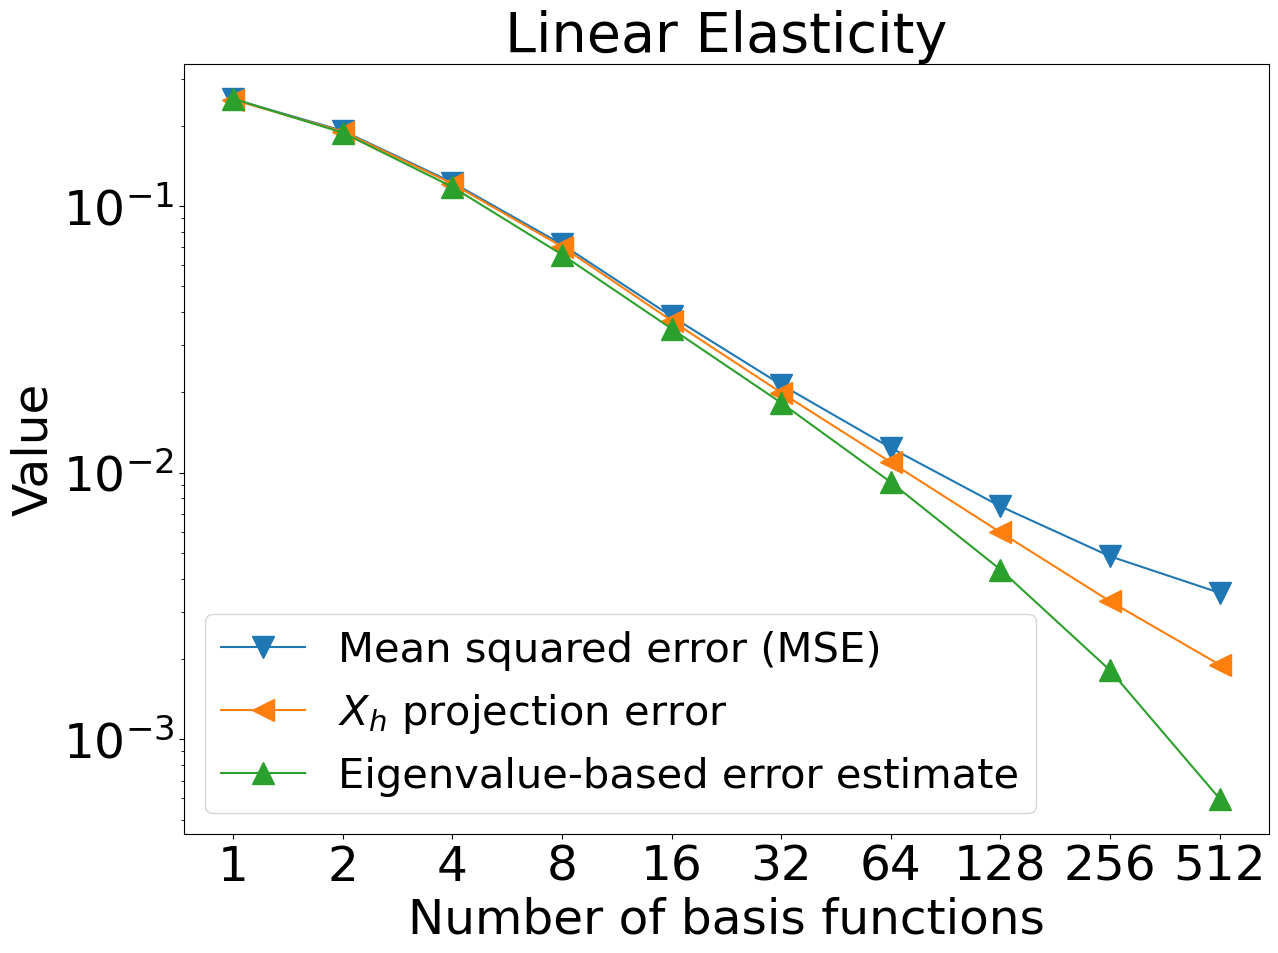

In [22]:
plt.figure(figsize=(14,10))
plt.plot(num_basis_list, mean_reduced_basis_mse_error_record, marker='v', markersize=16, label='Mean squared error (MSE)')
plt.plot(num_basis_list, mean_Xh_projection_error_record, marker='<',  markersize=16, label=r'$X_h$ projection error')
plt.plot(num_basis_list, error_estimate_by_trailing_eigenvalues_list, marker='^', markersize=16, label='Eigenvalue-based error estimate')
plt.xscale('log', base=2)
plt.yscale('log', base=10)
plt.xlabel('Number of basis functions', fontsize=35)
plt.ylabel('Value',fontsize=35)
plt.xticks(num_basis_list, num_basis_list, fontsize=35)
plt.yticks(fontsize=35)
plt.legend(fontsize=30, loc='lower left')
plt.title('Linear Elasticity', fontsize=40)
plt.savefig(os.path.join(test_dataset_path, "analysis_error_compared_to_RT1xCG2_solution.png"), dpi=300, bbox_inches='tight')
plt.show()